<a href="https://colab.research.google.com/github/siriwatsc-debug/DADS7202-DeepLearning/blob/main/V5_MobileNet_R1_Add_BackBone_BL_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instruction

1. Prepare the environment
- WANDB_API_KEY จาก wandb.ai
- set dataset path from google drive
2. Inspect Model
- function gen_backbone_model_and_weights เลือก backbone model
3. Load Dataset
- ทำ augmentation ของ train_transform, val_test_transform
4. Train model
- 4.1 FineTuneModel class edit backbone model refer to (2)
- 4.1 function train_loop ในกรณีที่ option parameter ของ WandB ไม่ตรงกับ code ใน function นี้
- 4.3 sweep_configuration ตามต้องการ
- 4.3 wandb.agent แก้ count=5 (ลอง count=10 จะทำให้ colab ค้าง)
  - ถ้า run 2 รอบ - จะได้ count เป็น 10
5. Inference
- 5.1 เลือก Best sweep_id
- 5.2 เปลี่ยน num_experiment
- 5.2 comment best_run_config['epochs'] = 1
- 5.2 ตรง train_loop แก้ train_dataset ให้ถูกต้อง
- 5.3 ตรง evaluate แก้ test_dataset ให้ถูกต้อง

# 1. Prepare the environment

In [1]:
from google.colab import drive
drive.mount('/content/drive', readonly=True)

Mounted at /content/drive


In [2]:
# Dataset, source

# Look at session folder mouth from GoogleDrive
# Example './drive/MyDrive/DADS7202/dataset'

#My path /content/drive/MyDrive/Master-DADS/DADS7202-DeepLearning/DL_Homework/dataset
DATASET_PATH = './drive/MyDrive/Master-DADS/DADS7202-DeepLearning/DL_Homework/dataset'

#My path for Backup Run : /content/drive/MyDrive/DeepLearning/dataset
#DATASET_PATH = '/content/drive/MyDrive/DeepLearning/dataset'

In [3]:
import os
import pandas as pd
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from google.colab import drive

# 2. ตั้งค่า Path ใหม่ตามที่คุณแจ้งมา
base_path = DATASET_PATH + '/train'
classes = ['Hawaiian', 'Margherita', 'Pepperoni', 'Seafood']
output_csv = 'pizza_metadata_D_to_J.csv'

train_f, val_f, test_f = None, None, None
data_list = []

print(f"🚀 กำลังประมวลผลข้อมูลจาก: {base_path}")

if not os.path.exists(base_path):
    print(f"❌ ยังหาโฟลเดอร์ไม่เจอ! ตรวจสอบว่าใน Drive มีโฟลเดอร์ 'DL for Pizza' จริงไหม")
else:
    for cls in classes:
        cls_dir = os.path.join(base_path, cls)
        if not os.path.exists(cls_dir):
            print(f"⚠️ ไม่พบโฟลเดอร์คลาส: {cls}")
            continue

        # ดึงไฟล์รูปภาพ
        files = sorted([f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

        if len(files) < 3:
            print(f"⚠️ {cls} มีรูปน้อยไปสำหรับการทำ Split")
            continue

        # --- หลักการแบ่งข้อมูล (Split Logic) ---
        # Stratified Split: Train 70%, Val 15%, Test 15%
        # train_f, temp_f = train_test_split(files, test_size=0.30, random_state=42)
        # val_f, test_f = train_test_split(temp_f, test_size=0.50, random_state=42)

        # Stratified Split: Train 60%, Val 20%, Test 20%
        train_f, temp_f = train_test_split(files, test_size=0.40, random_state=42)
        val_f, test_f = train_test_split(temp_f, test_size=0.50, random_state=42)

        for f in files:
            img_path = os.path.join(cls_dir, f)

            # กำหนดกลุ่ม Split
            if f in train_f: split_group = 'Train'
            elif f in val_f: split_group = 'Validation'
            else: split_group = 'Test'

            try:
                with Image.open(img_path) as img:
                    # ข้อมูล EDA (ข้อ 1)
                    w, h = img.size
                    color_mode = "RGB" if img.mode == 'RGB' else "Grayscale"
                    brightness = round(np.mean(np.array(img.convert('L'))), 2)

                    # เก็บข้อมูลเพื่อนำไป Paste ลง GSheet คอลัมน์ D:J
                    data_list.append({
                        'Image ID': f.split('.')[0], # คอลัมน์ A (ใช้อ้างอิง)
                        'Class': cls,
                        'W (pixels)': w,             # คอลัมน์ D
                        'H (pixels)': h,             # คอลัมน์ E
                        'Color': color_mode,         # คอลัมน์ F
                        'Brightness': brightness,    # คอลัมน์ G
                        'Split Group': split_group,  # คอลัมน์ H
                        'Is Augmented?': 'No',       # คอลัมน์ I
                        'Setting/Note': 'Standard'   # คอลัมน์ J
                    })
            except: pass

# 3. บันทึกและสรุปผล
if data_list:
    df = pd.DataFrame(data_list)
    df.to_csv(output_csv, index=False, encoding='utf-8-sig')
    print(f"✅ สำเร็จ! สร้างไฟล์ '{output_csv}' เรียบร้อย")
    print(df.groupby(['Split Group']).size()) # สรุปความสมดุล
else:
    print("😭 ข้อมูลว่างเปล่า เช็ค Path อีกรอบครับ")

🚀 กำลังประมวลผลข้อมูลจาก: ./drive/MyDrive/Master-DADS/DADS7202-DeepLearning/DL_Homework/dataset/train
✅ สำเร็จ! สร้างไฟล์ 'pizza_metadata_D_to_J.csv' เรียบร้อย
Split Group
Test          200
Train         600
Validation    200
dtype: int64


In [4]:
df

,Image ID,Class,W (pixels),H (pixels),Color,Brightness,Split Group,Is Augmented?,Setting/Note
0,H051,Hawaiian,600,400,RGB,154.70,Train,No,Standard
1,H052,Hawaiian,600,496,RGB,208.97,Train,No,Standard
2,H053,Hawaiian,359,319,RGB,156.46,Train,No,Standard
3,H054,Hawaiian,547,279,RGB,200.50,Train,No,Standard
4,H055,Hawaiian,505,474,RGB,134.58,Train,No,Standard
...,...,...,...,...,...,...,...,...,...
995,img196,Seafood,700,392,RGB,144.58,Test,No,Standard
996,img197,Seafood,1567,953,RGB,95.69,Train,No,Standard
997,img198,Seafood,467,301,RGB,161.90,Validation,No,Standard
998,img199,Seafood,897,715,RGB,163.96,Train,No,Standard


In [5]:
table = (
    # df.groupby(['Class', 'Brightness_bin', 'Split Group'], observed=False)
    df.groupby(['Class', 'Split Group'], observed=False)
      .size()
      .unstack(fill_value=0)
)

table['Total'] = table.sum(axis=1)
table.loc['Total'] = table.sum()
table

Split Group,Test,Train,Validation,Total
Class,,,,
Hawaiian,50,150,50,250
Margherita,50,150,50,250
Pepperoni,50,150,50,250
Seafood,50,150,50,250
Total,200,600,200,1000


In [6]:
train_idx = df[df['Split Group'] == 'Train'].index
test_idx = df[df['Split Group'] == 'Test'].index
val_idx = df[df['Split Group'] == 'Validation'].index

# เอา index ไปใช้ตอนทำ dataset
train_idx, test_idx, val_idx

(Index([  0,   1,   2,   3,   4,   7,   8,  11,  13,  14,
        ...
        982, 985, 989, 991, 992, 993, 994, 996, 998, 999],
       dtype='int64', length=600),
 Index([  5,  10,  16,  22,  24,  25,  28,  29,  30,  31,
        ...
        966, 968, 969, 972, 974, 981, 984, 986, 990, 995],
       dtype='int64', length=200),
 Index([  6,   9,  12,  15,  18,  19,  35,  42,  60,  67,
        ...
        946, 947, 962, 967, 975, 979, 983, 987, 988, 997],
       dtype='int64', length=200))

## Optional for train test split

In [7]:
labels = ['Dark', 'Bright']
bins = len(labels)
df['Brightness_Bin'] = pd.cut(
    df['Brightness'],
    bins=bins,
    labels=labels
)
df["Class_Brightness_Bin"] = df["Class"].astype(str) + "_" + df["Brightness_Bin"].astype(str)

labels = ['Small', 'Large']
bins = len(labels)
df['Area'] = df['W (pixels)'] * df['H (pixels)']
df['Area_bin'] = pd.cut(
    df['Area'],
    bins=bins,
    labels=labels
)

In [8]:
table = (
    df.groupby(['Class_Brightness_Bin', 'Split Group'], observed=False)
      .size()
      .unstack(fill_value=0)
)

table['Total'] = table.sum(axis=1)
table.loc['Total'] = table.sum()
table

Split Group,Test,Train,Validation,Total
Class_Brightness_Bin,,,,
Hawaiian_Bright,29,91,30,150
Hawaiian_Dark,21,59,20,100
Margherita_Bright,18,75,21,114
Margherita_Dark,32,75,29,136
Pepperoni_Bright,19,55,23,97
Pepperoni_Dark,31,95,27,153
Seafood_Bright,36,77,19,132
Seafood_Dark,14,73,31,118
Total,200,600,200,1000


In [9]:
new_train_df, tmp_df = train_test_split(
    df,
    test_size=0.4,
    stratify=df["Class_Brightness_Bin"],
    random_state=42
)

new_val_df, new_test_df = train_test_split(
    tmp_df,
    test_size=0.5,
    stratify=tmp_df["Class_Brightness_Bin"],
    random_state=42
)

df.loc[new_train_df.index, "New_Split_Group"] = "Train"
df.loc[new_val_df.index, "New_Split_Group"] = "Validation"
df.loc[new_test_df.index, "New_Split_Group"] = "Test"

table = (
    # df.groupby(['Class', 'Brightness_bin', 'Split Group'], observed=False)
    df.groupby(['Class_Brightness_Bin', 'New_Split_Group'], observed=False)
      .size()
      .unstack(fill_value=0)
)

table['Total'] = table.sum(axis=1)
table.loc['Total'] = table.sum()
table

New_Split_Group,Test,Train,Validation,Total
Class_Brightness_Bin,,,,
Hawaiian_Bright,30,90,30,150
Hawaiian_Dark,20,60,20,100
Margherita_Bright,23,68,23,114
Margherita_Dark,27,82,27,136
Pepperoni_Bright,20,58,19,97
Pepperoni_Dark,30,92,31,153
Seafood_Bright,27,79,26,132
Seafood_Dark,23,71,24,118
Total,200,600,200,1000


In [10]:
pd.crosstab(df["Class"], df["New_Split_Group"])

New_Split_Group,Test,Train,Validation
Class,,,
Hawaiian,50,150,50
Margherita,50,150,50
Pepperoni,50,150,50
Seafood,50,150,50


In [11]:
pd.crosstab(df["Brightness_Bin"], df["New_Split_Group"])

New_Split_Group,Test,Train,Validation
Brightness_Bin,,,
Dark,100,305,102
Bright,100,295,98


In [12]:
pd.crosstab(df["Class_Brightness_Bin"], df["New_Split_Group"])

New_Split_Group,Test,Train,Validation
Class_Brightness_Bin,,,
Hawaiian_Bright,30,90,30
Hawaiian_Dark,20,60,20
Margherita_Bright,23,68,23
Margherita_Dark,27,82,27
Pepperoni_Bright,20,58,19
Pepperoni_Dark,30,92,31
Seafood_Bright,27,79,26
Seafood_Dark,23,71,24


In [13]:
# train_idx = df[df['Split Group'] == 'Train'].index
# test_idx = df[df['Split Group'] == 'Test'].index
# val_idx = df[df['Split Group'] == 'Validation'].index

train_idx = df[df['New_Split_Group'] == 'Train'].index
test_idx = df[df['New_Split_Group'] == 'Test'].index
val_idx = df[df['New_Split_Group'] == 'Validation'].index

# เอา index ไปใช้ตอนทำ dataset
train_idx, test_idx, val_idx

(Index([  0,   5,   6,   7,  12,  13,  15,  16,  17,  18,
        ...
        982, 983, 989, 990, 992, 994, 996, 997, 998, 999],
       dtype='int64', length=600),
 Index([  1,  14,  21,  22,  23,  26,  44,  59,  60,  63,
        ...
        966, 967, 970, 975, 985, 987, 988, 991, 993, 995],
       dtype='int64', length=200),
 Index([  2,   3,   4,   8,   9,  10,  11,  30,  31,  41,
        ...
        941, 949, 956, 965, 968, 969, 979, 980, 984, 986],
       dtype='int64', length=200))

In [14]:
!pip install wandb

# Install dotenv to help manage API keys stored in ".env" file
!pip install python-dotenv

In [15]:
import wandb
print(f'WandB {wandb.__version__}')

WandB 0.25.1


In [16]:
#!echo "WANDB_API_KEY=XXX" > /content/.env

!echo "WANDB_API_KEY=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" >> /content/.env

# edit WANDB_API_KEY goto https://wandb.ai/settings to create api key

In [17]:
from dotenv import load_dotenv

load_dotenv(override=True)
WANDB_API_KEY = os.getenv('WANDB_API_KEY')

# Login with your WandB account
wandb.login(key=WANDB_API_KEY)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: siriwat-sc (siriwatsc) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [18]:
# WandB Connection Check: Verify that you are successfully logged in to WandB.
wandb_api = wandb.Api()

try:
    # api.viewer fetches the current authenticated user's details.
    # If this fails, it implies the API key is missing or invalid.
    user_info = wandb_api.viewer
    print(f"WandB Authentication Verified. Connected as: {user_info.entity}")

    WANDB_PROJECT_NAME = "DL_for_Pizza_MobileNet"
    WANDB_ENTITY = user_info.entity
    print(f"\nGlobal variable:\n- {WANDB_PROJECT_NAME = }\n- {WANDB_ENTITY = }")
except Exception as e:
    print("\n[Error] WandB Authentication Failed.")
    raise ConnectionError("Could not connect to WandB API. Please check your API key.") from e

WandB Authentication Verified. Connected as: siriwatsc

Global variable:
- WANDB_PROJECT_NAME = 'DL_for_Pizza_MobileNet'
- WANDB_ENTITY = 'siriwatsc'


In [19]:
# List all NVIDIA GPUs as available in this computer (or Colab's session)
!nvidia-smi -L

GPU 0: Tesla T4 (UUID: GPU-8972bb8d-5cac-1d6d-7c0a-5593ad253036)


In [20]:
!pip install torchinfo torchview

In [21]:
import sys
print( f"Python {sys.version}\n" )

import random
import time

import numpy as np
print( f"NumPy {np.__version__}\n" )

import matplotlib.pyplot as plt
%matplotlib inline

import torchinfo
print( f"torchinfo {torchinfo.__version__}\n" )
import torchview
print( f"torchview {torchview.__version__}\n" )

# https://docs.pytorch.org/vision/0.21/transforms.html
import torchvision
print( f"torchvision {torchvision.__version__}" )
import torchvision.transforms.v2 as T

import torch
print( f"PyTorch {torch.__version__}" )

# Get all available accelerators such as CUDA, MPS, MTIA, or XPU
num_accelerators = torch.accelerator.device_count()

if (num_accelerators <= 0):
    print("|- No hardware accelerators found. Using CPU only.")
else:
    print(f"|- PyTorch detected {num_accelerators} hardware accelerator(s)")
    print(f"|- PyTorch detected '{torch.accelerator.current_accelerator().type.upper()}' as the current accelerator")

    # Check cuda availability
    if torch.cuda.is_available():
        num_gpus = torch.cuda.device_count()
        print(f"|- PyTorch detected {num_gpus} CUDA GPU(s):")
    for i in range(num_gpus):
        print(f"   |- CUDA GPU {i}: {torch.cuda.get_device_name(i)}")

Python 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]

NumPy 2.0.2

torchinfo 1.8.0

torchview 0.2.7

torchvision 0.25.0+cu128
PyTorch 2.10.0+cu128
|- PyTorch detected 1 hardware accelerator(s)
|- PyTorch detected 'CUDA' as the current accelerator
|- PyTorch detected 1 CUDA GPU(s):
   |- CUDA GPU 0: Tesla T4


In [22]:
# Detect GPU (CUDA), Apple Silicon (MPS), or fallback to CPU
# 'device' is a scalar flag, not a tensor
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [23]:
# Reproducibility & Device Configuration
def set_seeds(seed=42):
    """Sets fixed seeds for reproducibility across all libraries."""
    random.seed(seed)     # Controls Python's built-in random numbers.
    np.random.seed(seed)  # Controls NumPy's random arrays.
    torch.manual_seed(seed)           # Controls CPU weight initialization.
    torch.cuda.manual_seed_all(seed)  # Controls GPU weight initialization.

    # Ensure deterministic behavior for some PyTorch operations
    torch.backends.cudnn.deterministic = True # Ensure the GPU doesn't use "fast but slightly random" algorithms for math
    torch.backends.cudnn.benchmark = False
    print(f"Seeds set to {seed} for reproducibility.")

# 2. Inspect Model

In [35]:
def gen_backbone_model_and_weights():
    #weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
    #model = torchvision.models.efficientnet_b0(weights=weights)

    # MobileNet V2 - Validation 89.2% (BL)
    # weights = torchvision.models.MobileNet_V2_Weights.DEFAULT
    # model = torchvision.models.mobilenet_v2(weights=weights)

    # MobileNet V3 Small (Fast) - Validation 75% (BL)
    # weights = torchvision.models.MobileNet_V3_Small_Weights.DEFAULT
    # model = torchvision.models.mobilenet_v3_small(weights=weights)

    # MobileNet V3 Large (Accurate) - Validation 92.8%? (BL)
    # model = models.mobilenet_v3_large(weights='DEFAULT')
    weights = torchvision.models.MobileNet_V3_Large_Weights.DEFAULT
    model = torchvision.models.mobilenet_v3_large(weights=weights)

    return model, weights

In [36]:
backbone_model, backbone_weights = gen_backbone_model_and_weights()
backbone_model

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bi

In [37]:
torchinfo.summary(backbone_model)

Layer (type:depth-idx)                             Param #
MobileNetV3                                        --
├─Sequential: 1-1                                  --
│    └─Conv2dNormActivation: 2-1                   --
│    │    └─Conv2d: 3-1                            432
│    │    └─BatchNorm2d: 3-2                       32
│    │    └─Hardswish: 3-3                         --
│    └─InvertedResidual: 2-2                       --
│    │    └─Sequential: 3-4                        464
│    └─InvertedResidual: 2-3                       --
│    │    └─Sequential: 3-5                        3,440
│    └─InvertedResidual: 2-4                       --
│    │    └─Sequential: 3-6                        4,440
│    └─InvertedResidual: 2-5                       --
│    │    └─Sequential: 3-7                        10,328
│    └─InvertedResidual: 2-6                       --
│    │    └─Sequential: 3-8                        20,992
│    └─InvertedResidual: 2-7                       --
│    │ 

In [38]:
backbone_weights.transforms()

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [39]:
import inspect

print(inspect.getsource(type(backbone_weights.transforms())))

class ImageClassification(nn.Module):
    def __init__(
        self,
        *,
        crop_size: int,
        resize_size: int = 256,
        mean: tuple[float, ...] = (0.485, 0.456, 0.406),
        std: tuple[float, ...] = (0.229, 0.224, 0.225),
        interpolation: InterpolationMode = InterpolationMode.BILINEAR,
        antialias: Optional[bool] = True,
    ) -> None:
        super().__init__()
        self.crop_size = [crop_size]
        self.resize_size = [resize_size]
        self.mean = list(mean)
        self.std = list(std)
        self.interpolation = interpolation
        self.antialias = antialias

    def forward(self, img: Tensor) -> Tensor:
        img = F.resize(img, self.resize_size, interpolation=self.interpolation, antialias=self.antialias)
        img = F.center_crop(img, self.crop_size)
        if not isinstance(img, Tensor):
            img = F.pil_to_tensor(img)
        img = F.convert_image_dtype(img, torch.float)
        img = F.normalize(img, mean=self.mea

In [40]:
backbone_weights.transforms().describe()

'Accepts ``PIL.Image``, batched ``(B, C, H, W)`` and single ``(C, H, W)`` image ``torch.Tensor`` objects. The images are resized to ``resize_size=[232]`` using ``interpolation=InterpolationMode.BILINEAR``, followed by a central crop of ``crop_size=[224]``. Finally the values are first rescaled to ``[0.0, 1.0]`` and then normalized using ``mean=[0.485, 0.456, 0.406]`` and ``std=[0.229, 0.224, 0.225]``.'

# 3. Load Dataset

In [41]:
import os
from torchvision import datasets

In [42]:
def ShowDatasetImage(dataset, mean, std):
  img, label = dataset

  # ถ้ามี Normalize ต้อง unnormalize ก่อน
  mean = torch.tensor(mean).view(3,1,1)
  std  = torch.tensor(std).view(3,1,1)

  img = img * std + mean  # unnormalize
  img = img.clamp(0,1)

  plt.imshow(img.permute(1,2,0))
  plt.title(f"Label: {label}")
  plt.axis("off")
  plt.show()

class DatasetsImageFolderCleaned(datasets.ImageFolder):
  def find_classes(self, directory):
    classes = [
      d for d in os.listdir(directory)
      if os.path.isdir(os.path.join(directory, d))
      and not d.startswith(".")
    ]
    classes.sort()
    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
    return classes, class_to_idx

In [43]:
backbone_mean = backbone_weights.transforms().mean
backbone_std = backbone_weights.transforms().std

print(f"Backbone Mean: {backbone_mean}")
print(f"Backbone Std: {backbone_std}")

Backbone Mean: [0.485, 0.456, 0.406]
Backbone Std: [0.229, 0.224, 0.225]


In [44]:
# Training: Augmentation + Normalization
train_transform = T.Compose([
    T.ToImage(),                          # 1. Convert to image tensor (no scaling)

    T.RandomResizedCrop(224, scale=(0.7,1.0)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.2,0.2,0.2,0.05),

    T.ToDtype(torch.float32, scale=True), # 4. Convert to Float and scale [0, 255] to [0, 1]
    T.Normalize(mean=backbone_mean, std=backbone_std),
])

# Validateing & Testing: No Augmentation
val_test_transform = T.Compose([
    T.ToImage(),
    T.Resize(256),
    T.CenterCrop(224),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=backbone_mean, std=backbone_std),
])

In [45]:
train_path = DATASET_PATH + '/train'

# test_path = DATASET_PATH + '/train' # ใช้ test จาก train_test_split idx ด้านบน

In [46]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
import numpy as np

train_dataset_full = DatasetsImageFolderCleaned(
    root=train_path,
    transform=None   # เดี๋ยวกำหนดทีหลัง
)

train_dataset = Subset(
    DatasetsImageFolderCleaned(root=train_path, transform=train_transform),
    train_idx
)

test_dataset = Subset(
    DatasetsImageFolderCleaned(root=train_path, transform=val_test_transform),
    test_idx
)

val_dataset = Subset(
    DatasetsImageFolderCleaned(root=train_path, transform=val_test_transform),
    val_idx
)

print(train_dataset_full.classes)
# print(test_dataset.classes)
print('train_dataset', len(train_dataset))
print('val_dataset', len(val_dataset))
print('test_dataset', len(test_dataset))

['Hawaiian', 'Margherita', 'Pepperoni', 'Seafood']
train_dataset 600
val_dataset 200
test_dataset 200


In [47]:
# Sample visual
train_loader = DataLoader(train_dataset, batch_size=12, shuffle=True)

# Sample 1 Batch
images, labels = next(iter(train_loader))

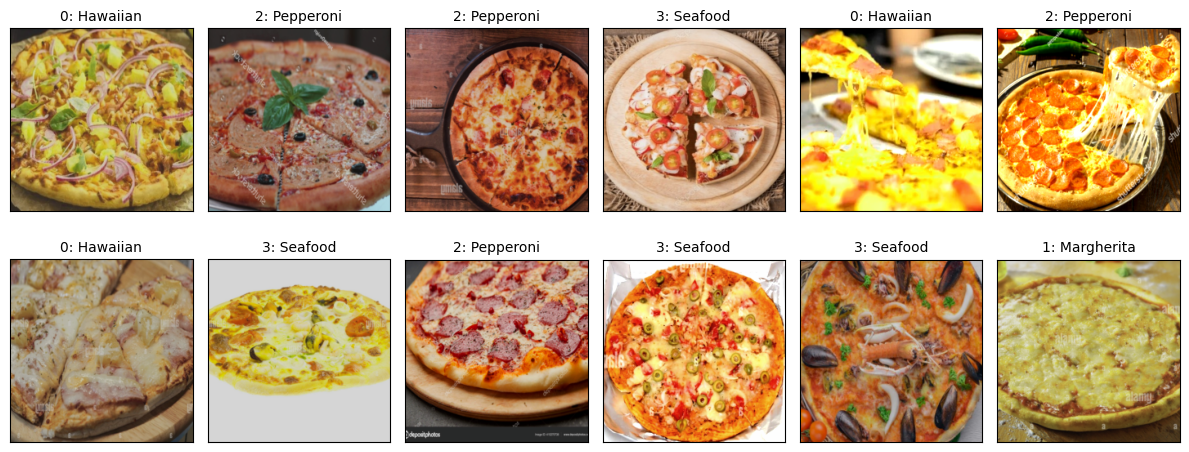

In [48]:
# Show image samples
class_names = train_dataset_full.classes

fig = plt.figure(figsize=(12, 5))

for i in range(len(images)):
    ax = fig.add_subplot(2, 6, i + 1, xticks=[], yticks=[])

    # Convert from (C, H, W) to (H, W, C) for plotting
    img = images[i].permute(1, 2, 0)
    img = img.numpy() * backbone_std + backbone_mean
    img = np.clip(img, 0, 1)

    plt.imshow(img)

    # Set title: "Index: Name" (e.g., "3: cat")
    ax.set_title(f"{labels[i].item()}: {class_names[labels[i]]}", fontsize=10)

plt.tight_layout()
plt.show()

# 4. Train Model

## 4.1 Prepare Class Function

In [49]:
save_weights_only = True

# Set project name
# WANDB_PROJECT_NAME = "DL_for_Pizza_MobileNet"

# Set project name
WANDB_PROJECT_NAME = "DL_for_Pizza_MobileNet_V3L" # New for V5 code

In [50]:
# --- VERSION 2: PYTORCH DEFAULT (Adaptive 7x7) ---
from types import SimpleNamespace

class FineTuneModel(torch.nn.Module):
    def __init__(self, _model, _weights, num_classes=10, config=None):
        super().__init__()

        if config is None:
            config = SimpleNamespace()

        dropout = getattr(config, "dropout", 0.2)
        # hidden_dim = getattr(config, "hidden_dim", 1280)
        # classifier_layers = getattr(config, "classifier_layers", 1)

        self.weights = _weights

        # Keep the pre-trained feature extractor and the adaptive pooling layer
        self.features = _model.features
        self.avgpool = _model.avgpool # This is AdaptiveAvgPool2d((7, 7))

        # Keep the massive (pre-trained) head
        # Only change the last FC layer to a new FC layer with our desired number of output classes
        # self.classifier = _model.classifier
        # self.classifier[-1] = torch.nn.Linear(1280, num_classes)

        # self.classifier = torch.nn.Sequential(
        #     torch.nn.Linear(1280, hidden_dim),
        #     torch.nn.ReLU(inplace=True),
        #     torch.nn.Dropout(p=dropout, inplace=False),
        #     torch.nn.Linear(hidden_dim, hidden_dim),
        #     torch.nn.ReLU(inplace=True),
        #     torch.nn.Dropout(p=dropout, inplace=False),
        #     torch.nn.Linear(hidden_dim, num_classes)
        # )

        self.classifier = torch.nn.Sequential(
            #torch.nn.Linear(1280, 640), # classifier[0] for MobileNetV2, EfficientNet
            #torch.nn.Linear(576, 640), # classifier[0] for MobileNetV3_small
            torch.nn.Linear(960, 1560), # classifier[0] for MobileNetV3_large

            torch.nn.ReLU(inplace=True),
            torch.nn.Dropout(p=dropout, inplace=False),
            torch.nn.Linear(1560, 640),
            torch.nn.ReLU(inplace=True),
            torch.nn.Dropout(p=dropout, inplace=False),
            torch.nn.Linear(640, num_classes)
        )

        # # Dynamic Layer
        # layers = []

        # # first layer
        # layers.append(torch.nn.Linear(1280, hidden_dim))
        # layers.append(torch.nn.ReLU(inplace=True))
        # layers.append(torch.nn.Dropout(dropout))

        # # middle hidden layers
        # for _ in range(classifier_layers - 1):
        #     layers.append(torch.nn.Linear(hidden_dim, hidden_dim))
        #     layers.append(torch.nn.ReLU(inplace=True))
        #     layers.append(torch.nn.Dropout(dropout))

        # # output layer
        # layers.append(torch.nn.Linear(hidden_dim, num_classes))
        # self.classifier = torch.nn.Sequential(*layers)

        # Freeze all parameters in the model
        # Tell PyTorch to exclude them from gradient computation during backpropagation to save memory and computation time
        for param in self.parameters():
            param.requires_grad = False

        # Unfreeze only the parameters in the last layer
        # for param in self.classifier[-1].parameters():
        #     param.requires_grad = True

        # # Unfreeze all classifier
        for param in self.classifier.parameters():
            param.requires_grad = True

    def forward(self, x):
        x = self.features(x)   # Output shape: [1, 512, 7, 7]
        x = self.avgpool(x)    # Output shape: [1, 512, 7, 7]

        # Flatten everything except the batch dimension (dim 0)
        # 512 * 7 * 7 = 25,088 features
        x = torch.flatten(x, 1)

        return self.classifier(x)


In [51]:
def save_model(model, optimizer, epoch, save_weights_only=True, save_path=''):
    if save_path == '': return
    """
    Locally save the given model to disk

    Args:
        model (torch.nn.Module): The PyTorch model to be saved.
        optimizer (torch.optim.Optimizer): The optimizer associated.
        epoch (int): The current epoch number (the first epoch is 1).
        save_weights_only (bool): If True, only the model's weights (.pt) will be saved.
            Otherwise, the full state dictionary (.tar) will be saved.
            Default is to use the global variable 'save_weights_only'.
        save_path (str): The local path to save the model file.
            Default is to use the global variable 'best_model_path'.
    """
    if save_weights_only:
        # Weights only: lightweight and portable
        torch.save(model.state_dict(), save_path)
        # print(f"---- Epoch {epoch+1:03d}: Weights saved to '{save_path}'")
    else:
        # Full Checkpoint: includes all metadata to resume training
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict()
        }
        torch.save( checkpoint, save_path )
        # print(f"---- Epoch {epoch+1:03d}: Full checkpoint saved to '{save_path}'")

In [52]:
from tqdm.notebook import tqdm
from sklearn.metrics import f1_score

def get_sample_weight(model):
    return model.classifier[-1].weight[-1].cpu().detach().numpy()[:3]

def train_loop(model=None, config=None, fn_log=None, fn_save=None, _train_dataset=None, _val_dataset=None, early_stop_step=10):
    # train_loader = DataLoader(_train_dataset, batch_size=config.batch_size, shuffle=True)
    # val_loader = DataLoader(_val_dataset, batch_size=config.batch_size)
    train_loader = DataLoader(
        _train_dataset,
        batch_size=config.batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    val_loader = DataLoader(
        _val_dataset,
        batch_size=config.batch_size,
        num_workers=2,
        pin_memory=True
    )

    # Only pass parameters that have 'requires_grad = True' to optimizer
    # This ensures the optimizer doesn't waste memory or computation on frozen weights
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    if config.optimizer == "adam":
        optimizer = torch.optim.Adam(trainable_params, lr=config.learning_rate, weight_decay=1e-4)
    elif config.optimizer == "sgd":
        optimizer = torch.optim.SGD(trainable_params, lr=config.learning_rate, momentum=0.9)

    # CrossEntropyLoss internally computes Softmax + NLLLoss.
    # This is why our models do NOT have a Softmax layer at the end.
    criterion = torch.nn.CrossEntropyLoss()
    best_v_loss = float('inf')
    best_v_acc = -float('inf')
    best_v_f1 = -float('inf')

    sample_best_weight = None

    history = {'t_loss': [], 't_acc': [], 'v_loss': [], 'v_acc': [], 'v_f1': []}

    counter_early_stop = 0
    for epoch in range(config.epochs):
        epoch_start = time.time()

        # --- TRAINING PHASE ---
        model.train()
        running_loss = 0.0
        correct_samples = 0
        samples_processed = 0

        all_preds = []
        all_labels = []
        pbar = tqdm(train_loader, desc=f"Train Epoch {epoch+1} | Batch", leave=False)
        for images, labels in pbar:
            pbar.set_postfix({"best_v_f1": f"{best_v_f1:.4f}"})
            images, labels = images.to(device), labels.to(device)
            current_batch_size = images.shape[0] # Handle potential smaller final batch

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # Accumulate loss multiplied by batch size to get total sample loss
            running_loss += loss.item() * current_batch_size
            samples_processed += current_batch_size

            # Accumulate the number of correct predictions
            preds = outputs.argmax(dim=1)
            correct_samples += (preds == labels).sum().item()

            # ⭐ เก็บไว้คำนวณ F1
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        avg_train_loss = running_loss / samples_processed
        avg_train_acc = (correct_samples / samples_processed) * 100
        avg_train_f1 = f1_score(all_labels, all_preds, average='weighted')

        # --- VALIDATION PHASE ---
        model.eval()
        v_running_loss = 0.0
        v_correct_samples = 0
        v_samples_processed = 0

        with torch.inference_mode():
            all_preds = []
            all_labels = []
            pbar = tqdm(val_loader, desc=f"Val Epoch {epoch+1} | Batch", leave=False)
            for images, labels in pbar:
                pbar.set_postfix({"best_v_f1": f"{best_v_f1:.4f}"})
                images, labels = images.to(device), labels.to(device)
                b_size = images.shape[0]

                outputs = model(images)
                loss = criterion(outputs, labels)

                v_running_loss += loss.item() * b_size
                preds = outputs.argmax(dim=1)
                v_correct_samples += (preds == labels).sum().item()
                v_samples_processed += b_size

                # ⭐ เก็บไว้คำนวณ F1
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        avg_v_loss = v_running_loss / v_samples_processed
        avg_v_acc = (v_correct_samples / v_samples_processed) * 100
        avg_v_f1 = f1_score(all_labels, all_preds, average='weighted')

        history['t_loss'].append(avg_train_loss)
        history['t_acc'].append(avg_train_acc)
        history['v_loss'].append(avg_v_loss)
        history['v_acc'].append(avg_v_acc)
        history['v_f1'].append(avg_v_f1)

        if avg_v_loss < best_v_loss:
            sample_best_weight = get_sample_weight(model)
            counter_early_stop = 0
            best_v_loss = avg_v_loss
            save_model(model, optimizer, epoch, save_weights_only, best_model_path)
            if fn_save:
                fn_save(best_model_path, policy="now")
        else:
            counter_early_stop += 1

        epoch_duration = time.time() - epoch_start

        if best_v_acc < avg_v_acc:
            best_v_acc = avg_v_acc
        if best_v_f1 < avg_v_f1:
            best_v_f1 = avg_v_f1

        if fn_log:
            fn_log({
                "avg_train_loss": avg_train_loss,
                "avg_train_acc": avg_train_acc,
                "avg_train_f1": avg_train_f1,
                "avg_v_loss": avg_v_loss,
                "avg_v_acc": avg_v_acc,
                "avg_v_f1": avg_v_f1,
                "best_v_loss": best_v_loss,
                "best_v_acc": best_v_acc,
                "best_v_f1": best_v_f1,
                "epoch": epoch + 1,
                "epoch_duration": epoch_duration,
                "sample_best_weight": sample_best_weight
            })

        # print(f"Done Epoch {epoch+1} | Time: {epoch_duration:.4f}s | Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2f}% | Val Loss: {avg_v_loss:.4f} | Val Acc: {avg_v_acc:.2f}%")

        if counter_early_stop > early_stop_step:
            print(f"Early stopping at epoch {epoch} | best_v_loss: {(best_v_loss):.4f} | avg_v_loss: {(avg_v_loss):.4f}")
            print(f"Train Finished. | best_v_f1: {(best_v_f1*100):.2f} | sample_best_weight {sample_best_weight}...")
            # break
            return

    print(f"Train Finished. | best_v_f1: {(best_v_f1*100):.2f} | sample_best_weight {sample_best_weight}...")

    # ตัดทิ้ง
    # Final Evaluation on Test Set (Logged as summary)
    # test_mse, test_mae = evaluate(model, test_loader, criterion_mse, criterion_mae)
    # wandb.log({"test_mse": test_mse, "test_mae": test_mae})
    # print(f"Sweep Finished. Test MSE: {test_mse}")

def train_sweep(config=None):
    with wandb.init(config=config) as run:
        config = wandb.config
        set_seeds(42)

        _model, _weights = gen_backbone_model_and_weights()

        # model = FineTuneModel(_model, _weights, len(train_dataset_full.classes),
        #                       config.dropout, config.hidden_dim, config.classifier_layers)

        model = FineTuneModel(_model, _weights, len(train_dataset_full.classes), config=config)

        model = model.to(device)

        wandb.watch(model, log="all", log_freq=10)

        train_loop(model, config, wandb.log, wandb.save, train_dataset, val_dataset)

## *** If do not want to train the model skip to 5.1

## 4.2 Define model

In [53]:
# Sample define model,, this code reuse in train_sweep function
_model, _weights = gen_backbone_model_and_weights()

# num_class = 4
num_class = len(train_dataset_full.classes)

finetune_model = FineTuneModel(_model, _weights, num_class)
finetune_model

FineTuneModel(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), 

In [54]:
for name, param in finetune_model.named_parameters():
    print(f"{name:40} | requires_grad = {param.requires_grad}")

features.0.0.weight                      | requires_grad = False
features.0.1.weight                      | requires_grad = False
features.0.1.bias                        | requires_grad = False
features.1.block.0.0.weight              | requires_grad = False
features.1.block.0.1.weight              | requires_grad = False
features.1.block.0.1.bias                | requires_grad = False
features.1.block.1.0.weight              | requires_grad = False
features.1.block.1.1.weight              | requires_grad = False
features.1.block.1.1.bias                | requires_grad = False
features.2.block.0.0.weight              | requires_grad = False
features.2.block.0.1.weight              | requires_grad = False
features.2.block.0.1.bias                | requires_grad = False
features.2.block.1.0.weight              | requires_grad = False
features.2.block.1.1.weight              | requires_grad = False
features.2.block.1.1.bias                | requires_grad = False
features.2.block.2.0.weig

## 4.3 WandB Train

In [55]:
# Define WandB's Sweep Configuration for hyperparameter tuning

best_model_path = 'best_model.pth'

sweep_configuration = {
    'method': 'bayes',  # 'grid', 'random', or 'bayes'
    #'name': 'pizza_sweep',
    'name': 'pizza_MNV3_L2', # MobileNet V3 Large
    'metric': {
        'goal': 'maximize',

        # Set what indicator to use, when sweep.best_run() considers which run is the best
        'name': 'best_v_f1',
    },
    'parameters': {
        'batch_size': {'values': [16, 32, 64]},
        'dropout': {
            'values': [0.2, 0.3]
        },
        # 'hidden_dim': {
        #     'values': [1024, 1280, 1536]
        # },
        # 'classifier_layers': {
        #     'values': [1,2]
        # },
        'learning_rate': {'distribution': 'log_uniform_values','max': 0.001, 'min': 0.00001},
        'optimizer': {'values': ['adam', 'sgd']},

        'epochs': {'value': 30},
    }
}


# sweep_configuration = {
#     'method': 'random',  # 'grid', 'random', or 'bayes'
#     'name': 'eff_classifier',
#     'metric': {
#         'goal': 'maximize',

#         # Set what indicator to use, when sweep.best_run() considers which run is the best
#         'name': 'avg_v_f1',
#     },
#     'parameters': {
#         'batch_size': {'values': [32, 64]},
#         'learning_rate': {'distribution': 'log_uniform_values','max': 0.001, 'min': 0.00001},
#         'optimizer': {'values': ['adam', 'sgd']},
#         'epochs': {'value': 100},
#     }
# }

In [56]:
api = wandb.Api()
projects = api.project(WANDB_PROJECT_NAME)

sweep_id = None

if len(projects._attrs) == 0:
    print('Create new sweep')
    sweep_id = wandb.sweep(sweep_configuration, project=WANDB_PROJECT_NAME)
else:
    sweep_ids = []
    for s in projects.sweeps():
        if s.name == sweep_configuration['name']:
            sweep_ids.append(s.id)

    if len(sweep_ids) > 1:
        print('Duplicate sweep name check in web ui')
    elif len(sweep_ids) == 1:
        sweep_id = sweep_ids[0]
    else:
        print('Create new sweep')
        sweep_id = wandb.sweep(sweep_configuration, project=WANDB_PROJECT_NAME)

sweep_id

Create new sweep
Create sweep with ID: dqh0frs2
Sweep URL: https://wandb.ai/siriwatsc/DL_for_Pizza_MobileNet_V3L/sweeps/dqh0frs2


'dqh0frs2'

In [ ]:
# if want to stop training cell below run wandb.finish()

wandb.finish()

In [ ]:
if sweep_id:
    # Run the sweep agent
    # count=5 means it will try 5 different hyperparameter combinations
    wandb.agent(sweep_id, function=train_sweep, count=1)

# 5. Inference

## 5.1 Download Best Model for Hyperparameter

In [57]:
import wandb
import pandas as pd

api = wandb.Api()
entity = api.viewer.entity
projects = api.projects(entity)

rows = []

for p in projects:
    sweeps = p.sweeps()

    if len(sweeps) == 0:
        continue

    for s in sweeps:
        rows.append({
            "Project": p.name,
            "Sweep Name": s.name,
            "Sweep ID": s.id,
            "Method": s.config.get("method"),
            "Created At": s.created_at,
            "Runs": len(s.runs)
        })

df = pd.DataFrame(rows)

df

,Project,Sweep Name,Sweep ID,Method,Created At,Runs
0,DL_for_Pizza_MN_V3L-1,pizza_MNV3_L-3,9c3kvs1o,bayes,2026-03-17T07:52:59Z,4
1,DL_for_Pizza_MN_V3L-1,pizza_MNV3_L-3,n0vz3k9q,bayes,2026-03-17T07:27:45Z,1
2,DL_for_Pizza_MN_V3L-1,pizza_MNV3_L-2,ytogtbo3,bayes,2026-03-17T06:42:31Z,1
3,DL_for_Pizza_MN_V3L-1,pizza_MNV3_L-1,0uponxqr,bayes,2026-03-17T05:16:00Z,4
4,DL_for_Pizza_MN_V3L-1,pizza_MNV3_L-1,zvl9yzjs,bayes,2026-03-17T05:13:23Z,0
5,DL_for_Pizza_MN_V3L-1,pizza_MNV3_L-1,f13sxsmp,bayes,2026-03-16T08:11:54Z,5
6,DL_for_Pizza_MobileNet_V3L-1_Aug_Flip_Gray_Rotate,pizza_MNV3_L2,w11hjb6e,bayes,2026-03-16T07:43:29Z,2
7,DL_for_Pizza_MobileNet_V3L-1_Aug_Flip_Gray_Rotate,pizza_MNV3_L2,b3rqcnje,bayes,2026-03-16T07:07:30Z,1
8,DL_for_Pizza_MobileNet_V3L-1_Aug_Flip_Gray_Rotate,pizza_MNV3_L2,doj4glez,bayes,2026-03-16T06:45:59Z,1
9,DL_for_Pizza_MobileNet_V3L-1_Aug_Flip_Gray_Rotate,pizza_MNV3_L2,orm5znql,bayes,2026-03-16T06:20:59Z,3


In [58]:
# Specify sweep_id to download model

# WANDB_PROJECT_NAME = 'DL_for_Pizza_EffNet_Param_Model'
WANDB_PROJECT_NAME = 'DL_for_Pizza_MobileNet_1'
# sweep_id = 'k1u3dnlo' # best v_f1 83%
sweep_id = '8pzixssz' # best v_f1 84.9%

#sweep_id = 'cvjkj6zs' #best v_f1 78.3%

best_model_path = 'best_model.pth'

# Construct sweep path
sweep_path = f"{WANDB_ENTITY}/{WANDB_PROJECT_NAME}/{sweep_id}" if WANDB_ENTITY else f"{WANDB_PROJECT_NAME}/{sweep_id}"
print(f"Analyzing sweep: {sweep_path}")

# Get the sweep object
sweep = api.sweep(sweep_path)

# metric_name = sweep.config['metric']['name']
metric_name = 'best_v_f1'

runs = sweep.runs
best_run = max(
    runs,
    key=lambda r: r.summary.get(metric_name, 0)
)

print(f"Best Run Found: {best_run.name} (ID: {best_run.id})")
print(f"Best {metric_name}: {best_run.summary.get(metric_name)}")

best_run.file(best_model_path).download(replace=True, root=".")

Analyzing sweep: siriwatsc/DL_for_Pizza_MobileNet_1/8pzixssz
Best Run Found: comic-sweep-1 (ID: a2m1rklz)
Best best_v_f1: 0.8491943311978257


<_io.TextIOWrapper name='./best_model.pth' mode='r' encoding='utf-8'>

In [44]:
print("Hyperparameters:")
for k, v in best_run.config.items():
    print(f"{k}: {v}")

Hyperparameters:
epochs: 50
dropout: 0.2
optimizer: adam
batch_size: 16
learning_rate: 1.8478589648004148e-05


In [45]:
from types import SimpleNamespace

best_run_config = best_run.config
# best_run_config['epochs'] = 1
best_config = SimpleNamespace(**best_run_config)

best_config

namespace(epochs=50,
          dropout=0.2,
          optimizer='adam',
          batch_size=16,
          learning_rate=1.8478589648004148e-05)

### 1st Evaluating

In [46]:
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    precision_recall_fscore_support,
    confusion_matrix
)

In [47]:
@torch.inference_mode()
def evaluate(model, device, loader):
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader, leave=False, desc=f"Model is predicting"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    # ===== Metrics =====
    avg_accuracy = accuracy_score(all_labels, all_preds)
    avg_precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    avg_recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    avg_f1 = f1_score(all_labels, all_preds, average='weighted')

    return {
        'Precision': avg_precision,
        'Recall': avg_recall,
        'F1': avg_f1,
        'Accuracy': avg_accuracy,
        'all_labels': all_labels,
        'all_preds': all_preds,
    }

In [48]:
best_model_path = 'best_model.pth'

if device.type == 'cpu':
    loaded_obj = torch.load(best_model_path, map_location=torch.device('cpu'))
else:
    loaded_obj = torch.load(best_model_path)

_model, _weights = gen_backbone_model_and_weights()
model_instance = FineTuneModel(_model, _weights, len(train_dataset_full.classes), best_config)

if isinstance(loaded_obj, dict) and 'model_state_dict' in loaded_obj:
    # It's a full checkpoint
    model_instance.load_state_dict(loaded_obj['model_state_dict'])
else:
    # It's a weight-only state_dict
    model_instance.load_state_dict(loaded_obj)

In [49]:
get_sample_weight(model_instance)

array([ 0.01636926,  0.03743456, -0.03788612], dtype=float32)

In [50]:
test_loader = DataLoader(test_dataset,
                           batch_size=best_config.batch_size)
result = evaluate(model_instance, device, test_loader)

Model is predicting:   0%|          | 0/13 [00:00<?, ?it/s]

In [51]:
pd.DataFrame([{
    "Precision": result["Precision"],
    "Recall": result["Recall"],
    "F1": result["F1"],
    "Accuracy": result["Accuracy"],
}])

,Precision,Recall,F1,Accuracy
0,0.818157,0.815,0.813416,0.815


In [52]:
final_models = {}
final_models[0] = model_instance

## *** IF SCORE IS NOT SATISFIED GOTO 4.1

## *** If do not want to Re-Train skip to 5.3

## 5.2 Re-Train model

In [90]:
WANDB_PROJECT_NAME_RETRAIN = f"{WANDB_PROJECT_NAME}_Retrain"
WANDB_PROJECT_NAME_RETRAIN

'DL_for_Pizza_MobileNet_1_Retrain'

In [91]:
# Regen new all_seeds
all_seeds = []
num_experiment = 10

for i in range(num_experiment):
  all_seeds.append(random.randrange(1000))
all_seeds.sort()
all_seeds

[364, 393, 468, 555, 607, 622, 814, 961, 972, 974]

In [92]:
# if want to continue specify seed

all_seeds = [80, 110, 177, 187, 324, 426, 500, 682, 724, 993]
all_seeds = [2, 4, 6, 8, 10]
all_seeds = [2]

# Specify seed that need to be trained

all_seeds = [2, 4, 6, 8, 10]
all_seeds

[2, 4, 6, 8, 10]

In [93]:
all_seed_names = [f"seed_{id}" for id in all_seeds]

api = wandb.Api()
runs = api.runs(f"{api.viewer.entity}/{WANDB_PROJECT_NAME_RETRAIN}")

all_runs = []
if runs._project_internal_id:
    for run in runs:
        if run.name in all_seed_names:
            all_runs.append(run.name)

if len(all_runs) > 0:
    print( all_runs )
    print(f"Run name exists, check in web ui")
else:
    print(f"Run name is ok, ready to Re-Train")

Run name is ok, ready to Re-Train


In [94]:
wandb.finish()
wandb.teardown()
# wandb.init(project=WANDB_PROJECT_NAME_RETRAIN)

In [ ]:
for seed in all_seeds:

    with wandb.init(
        project=WANDB_PROJECT_NAME_RETRAIN,
        name=f"seed_{seed}",
        resume="never"
    ) as run:

        best_model_path = f"final_model_seed_{seed}.pth"
        config = best_config
        set_seeds(seed)

        _model, _weights = gen_backbone_model_and_weights()

        model = FineTuneModel(_model, _weights, len(train_dataset_full.classes), config)

        model = model.to(device)

        wandb.watch(model, log="all", log_freq=10)

        train_loop(model, config, wandb.log, wandb.save, train_dataset, val_dataset)

        print("="*50)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


Seeds set to 2 for reproducibility.


Train Epoch 1 | Batch:   0%|          | 0/38 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Val Epoch 1 | Batch:   0%|          | 0/13 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Val Epoch 38 | Batch:   0%|          | 0/13 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Train Epoch 39 | Batch:   0%|          | 0/38 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


## 5.3 Download final_model

In [53]:
WANDB_PROJECT_NAME_RETRAIN = f"{WANDB_PROJECT_NAME}_Retrain"

In [58]:
all_seeds = [2, 4, 6, 8, 10]

#all_seeds = [4]

In [59]:
all_seed_names = [f"seed_{id}" for id in all_seeds]

api = wandb.Api()
runs = api.runs(f"{api.viewer.entity}/{WANDB_PROJECT_NAME_RETRAIN}")

rows = []
for run in runs:
    if run.name in all_seed_names:
        rows.append({
            "run_id": run.id,
            "run_name": run.name,
            "state": run.state,
            "created_at": run.created_at
        })

        best_model_path = f"final_model_{run.name}.pth"
        print( f"Downloading {best_model_path}" )
        try:
            run.file(best_model_path).download(replace=True, root=".")
        except wandb.CommError as e:
            print(f"⚠️ Warning: Could not download {best_model_path} for run {run.name}. Error: {e}")

df = pd.DataFrame(rows)

df

,run_id,run_name,state,created_at
0,jhl5i74o,seed_2,finished,2026-03-18T18:33:17Z
1,i3slj6cu,seed_4,finished,2026-03-18T19:23:08Z
2,6u7mzlos,seed_6,finished,2026-03-18T20:12:07Z
3,fe9n6c17,seed_8,finished,2026-03-18T21:00:06Z
4,4d8r3i4q,seed_10,finished,2026-03-18T21:48:32Z


In [60]:
# all_loaded_seeds = [110, 177, 187, 324, 426, 500, 682, 724, 80, 993]
# all_loaded_seeds = [1, 110, 177, 187, 324, 426, 500, 682, 724, 80, 993]

all_loaded_seeds = all_seeds

# all_loaded_seeds = [2, 110, 177, 187, 324]
# all_loaded_seeds = [4]

In [61]:
final_models = {}


for i, seed in enumerate(all_loaded_seeds):
    final_model_path = f"final_model_seed_{seed}.pth"

    if device.type == 'cpu':
        loaded_obj = torch.load(final_model_path, map_location=torch.device('cpu'))
    else:
        loaded_obj = torch.load(final_model_path)

    _model, _weights = gen_backbone_model_and_weights()
    model_instance = FineTuneModel(_model, _weights, len(train_dataset_full.classes), best_config)


    if isinstance(loaded_obj, dict) and 'model_state_dict' in loaded_obj:
        # It's a full checkpoint
        model_instance.load_state_dict(loaded_obj['model_state_dict'])

    else:
        # It's a weight-only state_dict
        model_instance.load_state_dict(loaded_obj)

    final_models[seed] = model_instance
    model_instance = None

In [63]:
get_sample_weight( final_models[4] )

array([-0.02486058, -0.0368998 ,  0.01520548], dtype=float32)

## 5.4 Get Mean ± SD

In [62]:
import pandas as pd
import numpy as np

def get_summary_metric(all_results, classes):
    records = []

    # classes = train_dataset_full.classes
    labels = range(len(classes))

    for r in all_results:

        precision, recall, f1, support = precision_recall_fscore_support(
            r['all_labels'],
            r['all_preds'],
            labels=labels,
            zero_division=0
        )

        cm = confusion_matrix(r['all_labels'], r['all_preds'], labels=labels)

        for i, cls in enumerate(classes):

            TP = cm[i, i]
            FP = cm[:, i].sum() - TP
            FN = cm[i, :].sum() - TP
            TN = cm.sum() - (TP + FP + FN)

            records.append({
                "class": cls,
                "precision": precision[i],
                "recall": recall[i],
                "f1": f1[i],
                "TP": TP,
                "FP": FP,
                "FN": FN,
                "TN": TN
            })

        records.append({
            "class": "ALL",
            "precision": r["Precision"],
            "recall": r["Recall"],
            "f1": r["F1"],
            "accuracy": r["Accuracy"]
        })

    df = pd.DataFrame(records)

    summary = df.groupby("class").agg(
        precision_mean=("precision","mean"),
        precision_sd=("precision","std"),
        recall_mean=("recall","mean"),
        recall_sd=("recall","std"),
        f1_mean=("f1","mean"),
        f1_sd=("f1","std"),
        TP_mean=("TP","mean"),
        FP_mean=("FP","mean"),
        FN_mean=("FN","mean"),
        TN_mean=("TN","mean"),
        acc_mean=("accuracy","mean"),
        acc_sd=("accuracy","std")
    )

    summary["Precision"] = summary.apply(
        lambda x: f"{x.precision_mean:.3f} ± {x.precision_sd:.2f}", axis=1)

    summary["Recall"] = summary.apply(
        lambda x: f"{x.recall_mean:.3f} ± {x.recall_sd:.2f}", axis=1)

    summary["F1"] = summary.apply(
        lambda x: f"{x.f1_mean:.3f} ± {x.f1_sd:.2f}", axis=1)

    summary["Accuracy"] = summary.apply(
        lambda x: "" if pd.isna(x.acc_mean)
        else f"{x.acc_mean:.3f} ± {x.acc_sd:.2f}", axis=1)

    summary = summary[[
        "Precision","Recall","F1","Accuracy",
        "TP_mean","FP_mean","FN_mean","TN_mean",
    ]]

    summary = summary.replace(np.nan, '')
    return summary

In [63]:
test_loader = DataLoader(test_dataset,
                           batch_size=best_config.batch_size)

In [64]:
all_results = []

bar = tqdm(final_models)

for i in bar:
    bar.set_description(f"Evaluating model")
    bar.set_postfix({"seed": i})
    result = {}

    metrics = evaluate(final_models[i], device, test_loader)
    result.update(metrics)

    all_results.append(result)

  0%|          | 0/5 [00:00<?, ?it/s]

Model is predicting:   0%|          | 0/13 [00:00<?, ?it/s]

Model is predicting:   0%|          | 0/13 [00:00<?, ?it/s]

Model is predicting:   0%|          | 0/13 [00:00<?, ?it/s]

Model is predicting:   0%|          | 0/13 [00:00<?, ?it/s]

Model is predicting:   0%|          | 0/13 [00:00<?, ?it/s]

In [65]:
pd.DataFrame(all_results).iloc[:, :-2]

,Precision,Recall,F1,Accuracy
0,0.821751,0.815,0.812954,0.815
1,0.817986,0.815,0.813149,0.815
2,0.803419,0.800,0.797521,0.800
3,0.816109,0.815,0.813827,0.815
4,0.798197,0.795,0.793012,0.795


In [66]:
summary_metric = get_summary_metric(all_results, train_dataset_full.classes)
summary_metric

,Precision,Recall,F1,Accuracy,TP_mean,FP_mean,FN_mean,TN_mean
class,,,,,,,,
ALL,0.811 ± 0.01,0.808 ± 0.01,0.806 ± 0.01,0.808 ± 0.01,,,,
Hawaiian,0.768 ± 0.02,0.936 ± 0.01,0.843 ± 0.01,,46.8,14.2,3.2,135.8
Margherita,0.816 ± 0.03,0.704 ± 0.03,0.755 ± 0.02,,35.2,8.0,14.8,142.0
Pepperoni,0.820 ± 0.01,0.780 ± 0.02,0.799 ± 0.01,,39.0,8.6,11.0,141.4
Seafood,0.842 ± 0.01,0.812 ± 0.03,0.827 ± 0.02,,40.6,7.6,9.4,142.4


metric	ความหมาย
- TP	ทาย class นี้ถูก
- FP	ทายว่าเป็น class นี้ แต่จริงไม่ใช่
- FN	จริงเป็น class นี้ แต่ทายพลาด
- TN	จริงไม่ใช่ class นี้ และทายว่าไม่ใช่

In [67]:
from collections import Counter

labels = [test_dataset.dataset.targets[i] for i in test_dataset.indices]
count = Counter(labels)

for i, c in count.items():
    print(test_dataset.dataset.classes[i], c)

Hawaiian 50
Margherita 50
Pepperoni 50
Seafood 50


## 5.5 visualize model prediction

In [67]:
import math

def visualize_test_results(model, device, temp_loader, _mean, _std, class_names, cols=6, show_label=True):
    model.to(device)
    model.eval()

    # Get batch
    images, labels = next(iter(temp_loader))
    images, labels = images.to(device), labels.to(device)

    with torch.inference_mode():
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        probs = torch.softmax(outputs, dim=1)
        pred_probs = probs[torch.arange(len(preds)), preds]

    # ----- Denormalize -----
    mean = torch.tensor(_mean).to(device).view(1, 3, 1, 1)
    std = torch.tensor(_std).to(device).view(1, 3, 1, 1)

    images = torch.clamp(images * std + mean, 0, 1)
    images = images.permute(0, 2, 3, 1).cpu()

    # ----- Dynamic grid -----
    total_images = len(images)
    rows = math.ceil(total_images / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(12, 5))

    # ถ้ามีรูปเดียว axes จะไม่เป็น array
    if total_images == 1:
        axes = [axes]

    axes = axes.flatten()

    for i in range(len(axes)):
        ax = axes[i]

        if i < total_images:
            img = images[i]
            ax.imshow(img)

            true_label = ''
            pred_prob = pred_probs[i].item() * 100
            color = 'black'

            if show_label:
                correct = preds[i] == labels[i]
                color = 'green' if correct else 'red'

                for spine in ax.spines.values():
                    spine.set_edgecolor(color)
                    spine.set_linewidth(3)

                true_label = f"\nT: {class_names[labels[i]]}"

            ax.set_title(
                f"P: {class_names[preds[i]]}\n{pred_prob:.1f}%" + true_label,
                color=color,
                fontsize=10
            )
        else:
            ax.axis("off")

        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    plt.show()

In [68]:
test_idx_tmp = list(test_idx)
np.random.shuffle(test_idx_tmp)
test_idx_tmp = pd.Index(test_idx_tmp)

test_dataset_tmp = Subset(
    DatasetsImageFolderCleaned(root=train_path, transform=val_test_transform),
    test_idx_tmp
)
test_loader = DataLoader(test_dataset_tmp, batch_size=6, shuffle=False)

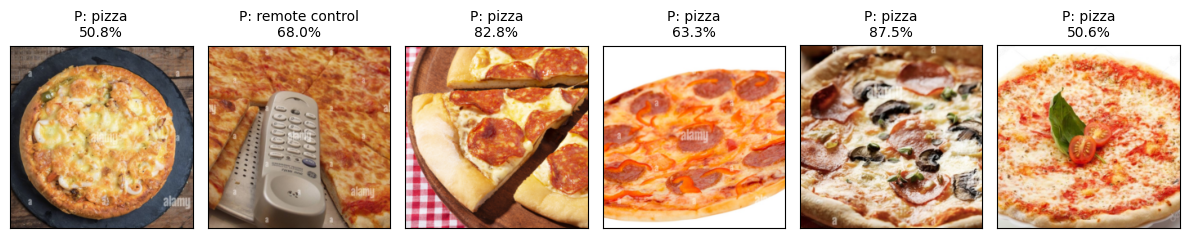

In [69]:
_model, _weight = gen_backbone_model_and_weights()
visualize_test_results(backbone_model, device, test_loader, backbone_mean, backbone_std, backbone_weights.meta["categories"], show_label=False)

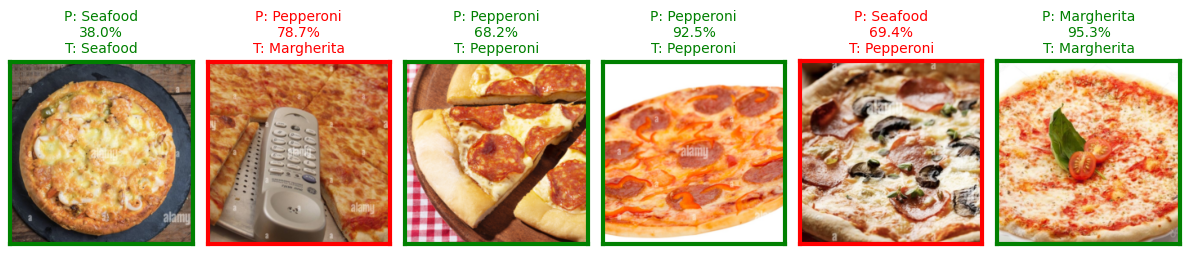

In [70]:
visualize_test_results(final_models[4], device, test_loader, backbone_mean, backbone_std, train_dataset_full.classes)

In [71]:
# Test backbone model for Base line

backbone_model_result = evaluate(backbone_model, device, test_loader)

backbone_categories = list(map(lambda x: x.lower(), backbone_weights.meta['categories']))
#backbone_y_true = [ backbone_categories.index('pizza') ] * len(backbone_model_result['all_labels'])
backbone_y_true = backbone_model_result['all_labels']
backbone_y_pred = backbone_model_result['all_preds']

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(backbone_y_true, backbone_y_pred)

precision = precision_score(backbone_y_true, backbone_y_pred, average='macro', zero_division=0)
recall = recall_score(backbone_y_true, backbone_y_pred, average='macro', zero_division=0)
f1 = f1_score(backbone_y_true, backbone_y_pred, average='macro', zero_division=0)

print("Backbone score")
print("Accuracy:", accuracy)
print("F1:", f1)
print("Precision:", precision)
print("Recall:", recall)

Model is predicting:   0%|          | 0/34 [00:00<?, ?it/s]

Backbone score
Accuracy: 0.0
F1: 0.0
Precision: 0.0
Recall: 0.0


# 6. GradCAM Analysis

In [72]:
!pip install grad-cam --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 52.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [73]:
import torch
import torchvision
from torchvision import transforms
from PIL import Image
import cv2
import numpy as np

import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [74]:
def show_gradcam_batch(model_cam, data_list, device, classes, target_layers):

    # 1. Clone model
    model_cam.eval()

    for m in model_cam.modules():
        if hasattr(m, "inplace"):
            m.inplace = False

    cam = GradCAM(model=model_cam, target_layers=target_layers)

    num_images = len(data_list)
    fig, axes = plt.subplots(num_images, 3, figsize=(5.5, 1.6 * num_images), squeeze=False)

    for i, (img_tensor, true_label) in enumerate(data_list):
        input_tensor = img_tensor.unsqueeze(0).to(device)
        input_tensor.requires_grad_(True)

        grayscale_cam = cam(input_tensor=input_tensor)[0]

        with torch.no_grad():
            output = model_cam(input_tensor)
            pred_idx = output.argmax(1).item()
            conf = torch.softmax(output, dim=1)[0][pred_idx].item()

        img_plot = img_tensor.permute(1, 2, 0).cpu().numpy()

        mean = backbone_mean
        std = backbone_std

        img_plot = std * img_plot + mean
        img_plot = np.clip(img_plot, 0, 1)

        cam_image = show_cam_on_image(img_plot, grayscale_cam, use_rgb=True)
        true_class = classes[true_label]

        title_text = f"True: {true_class}\nPred: {classes[pred_idx]} ({conf*100:.1f}%)"

        # --- กำหนดสีตามผลการทาย ---
        border_color = "green" if pred_idx == true_label else "red"
        line_width = 3

        ax_orig = axes[i, 0]
        ax_cam = axes[i, 1]
        ax_heat = axes[i, 2]

        ax_orig.imshow(img_plot)
        if i == 0: ax_orig.set_title("Original", fontsize=11)

        # --- เปลี่ยนสีตัวหนังสือตรงนี้ครับ ---
        ax_orig.text(-0.15, 0.5, title_text, transform=ax_orig.transAxes,
                     fontsize=9, ha='right', va='center',
                     color=border_color, fontweight='bold')

        ax_cam.imshow(cam_image)
        if i == 0: ax_cam.set_title("GradCAM", fontsize=11)

        ax_heat.imshow(grayscale_cam, cmap="jet")
        if i == 0: ax_heat.set_title("Heatmap", fontsize=11)

        # วนลูปจัดการกรอบ
        for ax in [ax_orig, ax_cam, ax_heat]:
            ax.set_xticks([])
            ax.set_yticks([])

            for spine in ax.spines.values():
                spine.set_edgecolor(border_color)
                spine.set_linewidth(line_width)

    fig.subplots_adjust(left=0.3, right=0.98, top=0.9, bottom=0.05, hspace=0.05, wspace=0.02)

    plt.show()

In [75]:
# 🔴 แดง	model สนใจมากที่สุด
# 🟠 ส้ม / เหลือง	สนใจปานกลาง
# 🟢 เขียว	สนใจน้อย
# 🔵 น้ำเงิน	แทบไม่ใช้ในการตัดสินใจ

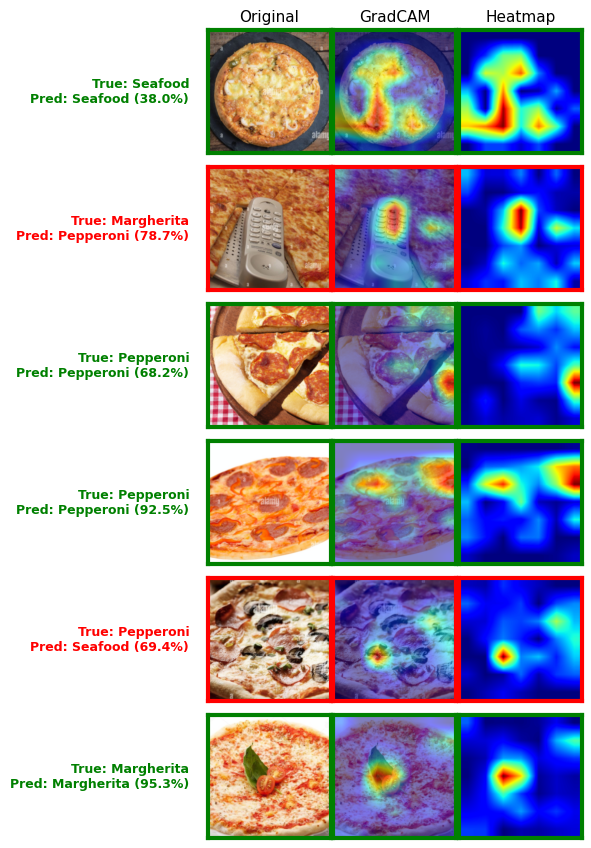

In [76]:
# load model
model = final_models[4]

target_layers = [model.features[-1]]

data_subset = [test_dataset_tmp[i] for i in range(6)]
show_gradcam_batch(model, data_subset, device, train_dataset_full.classes, target_layers)

In [77]:
result = evaluate(model, device, test_loader)

y_true = result['all_labels']
y_pred = result['all_preds']

classes = train_dataset_full.classes

Model is predicting:   0%|          | 0/34 [00:00<?, ?it/s]

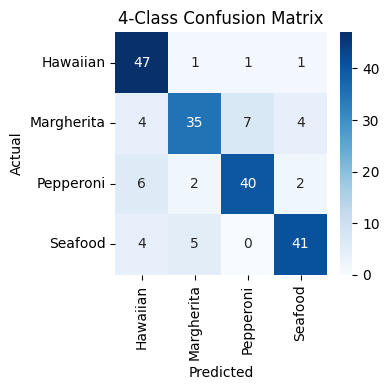

              precision    recall  f1-score   support

    Hawaiian       0.77      0.94      0.85        50
  Margherita       0.81      0.70      0.75        50
   Pepperoni       0.83      0.80      0.82        50
     Seafood       0.85      0.82      0.84        50

    accuracy                           0.81       200
   macro avg       0.82      0.81      0.81       200
weighted avg       0.82      0.81      0.81       200



In [78]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(4, 4))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                 xticklabels=classes, yticklabels=classes)

# 1. Fit Y-axis text horizontal
plt.yticks(rotation=0, ha='right')

# 2. Fit X-axis text vertical
plt.xticks(rotation=90, ha='center')

plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('4-Class Confusion Matrix')

# Adjust layout to ensure labels aren't cut off
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=classes))

# BACKUP

In [ ]:
!pip install torchinfo torchview --quiet
!pip install grad-cam --quiet

In [ ]:
import urllib.request
from PIL import Image

url = "https://github.com/pytorch/hub/raw/master/images/dog.jpg"

urllib.request.urlretrieve(url, "dog.jpg")

img = Image.open("dog.jpg").convert("RGB")

img

In [ ]:
import torch
import torchvision
from torchvision import transforms
from PIL import Image
import numpy as np
import cv2

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# model
model_for_test_gc = torchvision.models.resnet50(pretrained=True)
model_for_test_gc.eval()

# layer ที่ใช้ทำ GradCAM
target_layers = [model_for_test_gc.layer4[-1]]

# image
img = Image.open("dog.jpg").convert("RGB")

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

input_tensor = transform(img).unsqueeze(0)

# GradCAM
cam = GradCAM(model=model_for_test_gc, target_layers=target_layers)

targets = None
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)

cam_img = grayscale_cam[0]

# overlay
rgb_img = np.array(img.resize((224,224))) / 255.0
visualization = show_cam_on_image(
    rgb_img,
    cam_img,
    use_rgb=True,
    image_weight=0.5
)

import matplotlib.pyplot as plt
plt.imshow(visualization)
plt.axis('off')


In [ ]:
# plt.imshow(rgb_img)
# plt.contour(cam_img, levels=5, colors='red')
# plt.axis("off")

plt.imshow(cam_img, cmap="jet")
plt.colorbar()
plt.axis("off")

In [ ]:
from torchvision import transforms

backbone_mean = [0.485, 0.456, 0.406]
backbone_std = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(backbone_mean, backbone_std)
])

img_tensor = transform(img)

In [ ]:
classes = [f"class_{i}" for i in range(1000)]

In [ ]:
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

# device = "cuda" if torch.cuda.is_available() else "cpu"
data_list = [(img_tensor, 207)]   # 207 ≈ golden retriever ใน ImageNet


model_for_test_gc_copy = copy.deepcopy(model_for_test_gc).to(device)
target_layers = [model_for_test_gc_copy.layer4[-1]]

show_gradcam_batch(model_for_test_gc_copy, data_list, device=device, classes=classes, target_layers=target_layers)

In [ ]:
train_loop(final_model, best_config, None, None)

In [ ]:
print(final_model.classifier[3].weight)
print(final_model.classifier[6].weight)

In [ ]:
test_loader = DataLoader(test_dataset, batch_size=best_config.batch_size)

In [ ]:
result = evaluate(final_model, test_loader)

In [ ]:
results = [
  {'accuracy':0.88, 'precision':0.87, 'recall':0.86, 'f1_score':0.87},
  {'accuracy':0.90, 'precision':0.89, 'recall':0.88, 'f1_score':0.89},
]
df = pd.DataFrame(results)
summary = df.agg(['mean', 'std'])
summary.T

In [ ]:
set_seeds(random.randrange(1000))

In [ ]:
import wandb

api = wandb.Api()
entity = api.viewer.entity

projects = api.projects(entity)

for p in projects:
    print(f"\n📁 Project: {p.name}")
    if p.name == 'DL_for_Pizza': continue
    # if p.name != 'DL_for_Pizza': continue

    sweeps = p.sweeps()   # ใช้จาก object p ตรง ๆ

    if len(sweeps) == 0:
        print("   No sweeps")
        continue

    for s in sweeps:
        print(s)
        print(f"   🔹 Sweep ID: {s.id}")
        print(f"      Created At: {s.created_at}")
        print(f"      Name: {s.name}")
        print(f"      Method: {s.config.get('method')}")
        print(f"      Runs: {len(s.runs)}")

In [ ]:
# =================================================================
# TRAINING LOOP (Sample-Based Accumulation)
# =================================================================
def train_and_validate(model, train_loader, val_loader, device, epochs=5):

    model.to(device)

    # Only pass parameters that have 'requires_grad = True' to optimizer
    # This ensures the optimizer doesn't waste memory or computation on frozen weights
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(trainable_params, lr=1e-4)

    # CrossEntropyLoss internally computes Softmax + NLLLoss.
    # This is why our models do NOT have a Softmax layer at the end.
    criterion = torch.nn.CrossEntropyLoss()

    history = {'t_loss': [], 't_acc': [], 'v_loss': [], 'v_acc': []}

    for epoch in range(epochs):
        epoch_start = time.time()

        # --- TRAINING PHASE ---
        model.train()
        running_loss = 0.0
        correct_samples = 0
        samples_processed = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            current_batch_size = images.shape[0] # Handle potential smaller final batch

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # Accumulate loss multiplied by batch size to get total sample loss
            running_loss += loss.item() * current_batch_size
            samples_processed += current_batch_size

            # Accumulate the number of correct predictions
            preds = outputs.argmax(dim=1)
            correct_samples += (preds == labels).sum().item()

        avg_train_loss = running_loss / samples_processed
        avg_train_acc = (correct_samples / samples_processed) * 100

        # --- VALIDATION PHASE ---
        model.eval()
        v_running_loss = 0.0
        v_correct_samples = 0
        v_samples_processed = 0

        with torch.inference_mode():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                b_size = images.shape[0]

                outputs = model(images)
                loss = criterion(outputs, labels)

                v_running_loss += loss.item() * b_size
                preds = outputs.argmax(dim=1)
                v_correct_samples += (preds == labels).sum().item()
                v_samples_processed += b_size

        avg_v_loss = v_running_loss / v_samples_processed
        avg_v_acc = (v_correct_samples / v_samples_processed) * 100

        history['t_loss'].append(avg_train_loss)
        history['t_acc'].append(avg_train_acc)
        history['v_loss'].append(avg_v_loss)
        history['v_acc'].append(avg_v_acc)

        epoch_duration = time.time() - epoch_start
        print(f"Epoch {epoch+1} | Time: {epoch_duration:.4f}s | Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2f}% | Val Loss: {avg_v_loss:.4f} | Val Acc: {avg_v_acc:.2f}%")

    return history

In [ ]:
print("Training the first custom model ...")

model = FineTuneModel(backbone_model, backbone_weights, len(train_dataset.classes))

# NVIDIA A100 (40GB VRAM): about 9 seconds per epoch
# G4 GPU: NVIDIA RTX PRO 6000 Blackwell (95.6GB VRAM): about 2.5 seconds per epoch
history1 = train_and_validate(model, train_loader, test_loader, device, epochs=10)

# 5. xxxx Inference

In [ ]:
import math

def visualize_test_results(model, device, temp_loader, _mean, _std, class_names, cols=5):
    model.to(device)
    model.eval()

    # Get batch
    images, labels = next(iter(temp_loader))
    images, labels = images.to(device), labels.to(device)

    with torch.inference_mode():
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        probs = torch.softmax(outputs, dim=1)
        pred_probs = probs[torch.arange(len(preds)), preds]

    # ----- Denormalize -----
    mean = torch.tensor(_mean).to(device).view(1, 3, 1, 1)
    std = torch.tensor(_std).to(device).view(1, 3, 1, 1)

    images = torch.clamp(images * std + mean, 0, 1)
    images = images.permute(0, 2, 3, 1).cpu()

    # ----- Dynamic grid -----
    total_images = len(images)
    rows = math.ceil(total_images / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))

    # ถ้ามีรูปเดียว axes จะไม่เป็น array
    if total_images == 1:
        axes = [axes]

    axes = axes.flatten()

    for i in range(len(axes)):
        ax = axes[i]

        if i < total_images:
            img = images[i]
            ax.imshow(img)

            pred_prob = pred_probs[i].item() * 100
            correct = preds[i] == labels[i]
            color = 'green' if correct else 'red'

            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(3)

            ax.set_title(
                f"P: {class_names[preds[i]]} ({pred_prob:.1f})%\nT: {class_names[labels[i]]}",
                color=color,
                fontsize=9
            )
        else:
            ax.axis("off")

        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    plt.show()

In [ ]:
visualize_test_results(model, device, test_loader, mean, std, train_dataset.classes)